In [1]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import umap
import warnings
import matplotlib.pyplot as plt

plt.style.use('dark_background')

warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("samantas2020/online-retail-xlsx")
excel_file_path = os.path.join(path, 'Online Retail.xlsx')
df = pd.read_excel(excel_file_path)

100%|██████████| 21.8M/21.8M [00:00<00:00, 56.2MB/s]

Extracting files...


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.4 MB/s eta 0:00:00


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
has_nan = df.isnull().values.any()
print(has_nan)

True


In [6]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
nan_percentage = df.isnull().mean() * 100
print(nan_percentage)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [8]:
nan_rows = df[df.isnull().any(axis=1)]
print(nan_rows)

       InvoiceNo StockCode                      Description  Quantity  \
622       536414     22139                              NaN        56   
1443      536544     21773  DECORATIVE ROSE BATHROOM BOTTLE         1   
1444      536544     21774  DECORATIVE CATS BATHROOM BOTTLE         2   
1445      536544     21786               POLKADOT RAIN HAT          4   
1446      536544     21787            RAIN PONCHO RETROSPOT         2   
...          ...       ...                              ...       ...   
541536    581498    85099B          JUMBO BAG RED RETROSPOT         5   
541537    581498    85099C   JUMBO  BAG BAROQUE BLACK WHITE         4   
541538    581498     85150    LADIES & GENTLEMEN METAL SIGN         1   
541539    581498     85174                S/4 CACTI CANDLES         1   
541540    581498       DOT                   DOTCOM POSTAGE         1   

               InvoiceDate  UnitPrice  CustomerID         Country  
622    2010-12-01 11:52:00       0.00         NaN  Unit

In [9]:
print(df['Quantity'].describe())

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


In [10]:
df[df['Quantity'] < 0]['InvoiceNo'].value_counts().head()

,count
InvoiceNo,
C570867,101
C560540,57
C548460,45
C560855,41
C570828,39


In [11]:
print(df[df['InvoiceNo'] == 'C536379'])

    InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
141   C536379         D    Discount        -1 2010-12-01 09:41:00       27.5   

     CustomerID         Country  
141     14527.0  United Kingdom  


In [12]:
total_rows = len(df)

cancelled_count = df['InvoiceNo'].str.contains('C', na=False).sum()
cancelled_percentage = (cancelled_count / total_rows) * 100

print(f"Total number of transactions: {total_rows}")
print(f"Number of cancelled invoices: {cancelled_count}")
print(f"Percentage of cancelled invoices in the dataset: {cancelled_percentage:.2f}%")

Total number of transactions: 541909
Number of cancelled invoices: 9288
Percentage of cancelled invoices in the dataset: 1.71%


In [13]:
cancelled_orders = df[df['InvoiceNo'].str.contains('C', na=False)]
print(f"Total number of cancelled rows: {len(cancelled_orders)}")

Total number of cancelled rows: 9288


In [14]:
negative_quantity = df[df['Quantity'] < 0]
print(f"Number of rows with negative quantity: {len(negative_quantity)}")

Number of rows with negative quantity: 10624


## Cleaning & Splitting

In [15]:
df.dropna(inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)

df = df[~df['InvoiceNo'].str.contains('C')]
df = df[df["Quantity"] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.sort_values('InvoiceDate', inplace=True)

split_date = df['InvoiceDate'].quantile(0.9)
train_df = df[df['InvoiceDate'] <= split_date]
val_df = df[df['InvoiceDate'] > split_date]

purchases_train = train_df.groupby(['CustomerID', 'InvoiceNo'])['StockCode'].apply(list).tolist()
purchases_val = val_df.groupby(['CustomerID', 'InvoiceNo'])['StockCode'].apply(list).tolist()

purchases_train = [s for s in purchases_train if len(s) > 1]

In [16]:
df['Hour'] = df['InvoiceDate'].dt.hour
print(df['Hour'].head())

0    8
1    8
2    8
3    8
4    8
Name: Hour, dtype: int32


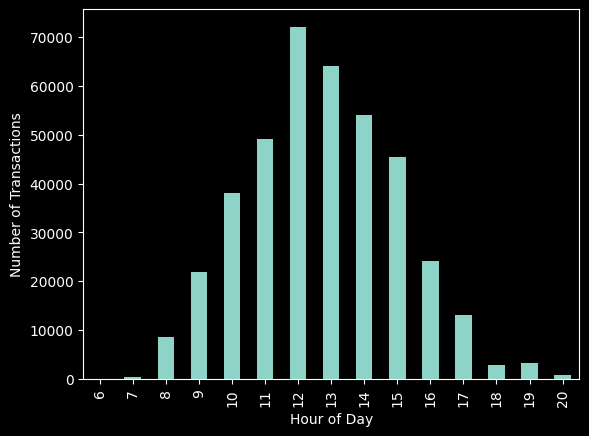

In [17]:
import matplotlib.pyplot as plt

df['InvoiceDate'].dt.hour.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.show()

## Training & Hit Rate

In [18]:
!pip install gensim

In [19]:
import numpy as np
from gensim.models import Word2Vec

model = Word2Vec(window=5, sg=1, negative=15, min_count=2, workers=4, vector_size=150)
model.build_vocab(purchases_train)
print("Training started with 30 epochs...")
model.train(purchases_train, total_examples=model.corpus_count, epochs=30)
model.init_sims(replace=True)

def calculate_hit_rate_weighted(model, sequences, k=10):
    hits, total = 0, 0

    for seq in sequences:
        if len(seq) < 2: continue

        input_items = seq[:-1]
        actual_item = seq[-1]

        try:

            recent_items = input_items[-3:]

            weights = [1, 2, 3][-len(recent_items):]

            weighted_vecs = []
            for i, item in enumerate(recent_items):
                if item in model.wv:
                    weighted_vecs.append(model.wv[item] * weights[i])

            if len(weighted_vecs) == 0: continue
            pred_vec = np.mean(weighted_vecs, axis=0)
            recs_data = model.wv.most_similar(positive=[pred_vec], topn=k)
            recs = [item[0] for item in recs_data]

            if actual_item in recs:
                hits += 1
            total += 1
        except:
            continue

    return hits / total if total > 0 else 0

final_hr = calculate_hit_rate_weighted(model, purchases_val, k=10)
print("-" * 40)
print(f"Weighted Strategy Hit Rate @ 10: {final_hr:.2%}")
print("-" * 40)

Training started with 30 epochs...


----------------------------------------
Weighted Strategy Hit Rate @ 10: 13.21%
----------------------------------------


In [20]:
item_lookup = df[['StockCode', 'Description']].drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
def suggest_items(model, basket, k=10):
    item_vectors = [model.wv[code] for code in basket if code in model.wv]
    if not item_vectors:
        return

    target_vec = np.mean(item_vectors, axis=0)
    similar_items = model.wv.most_similar(positive=[target_vec], topn=k)

    print("--- Current Basket Contains: ---")

    for code in basket:
        print(f"- {item_lookup.get(code, 'Unknown Item')} ({code})")

    print("\n--- Recommended Items for This Customer: ---")

    for i, (code, score) in enumerate(similar_items, 1):
        name = item_lookup.get(code, "Unknown Item")

        print(f"{i}. {name} (similarity score: {score:.2f})")

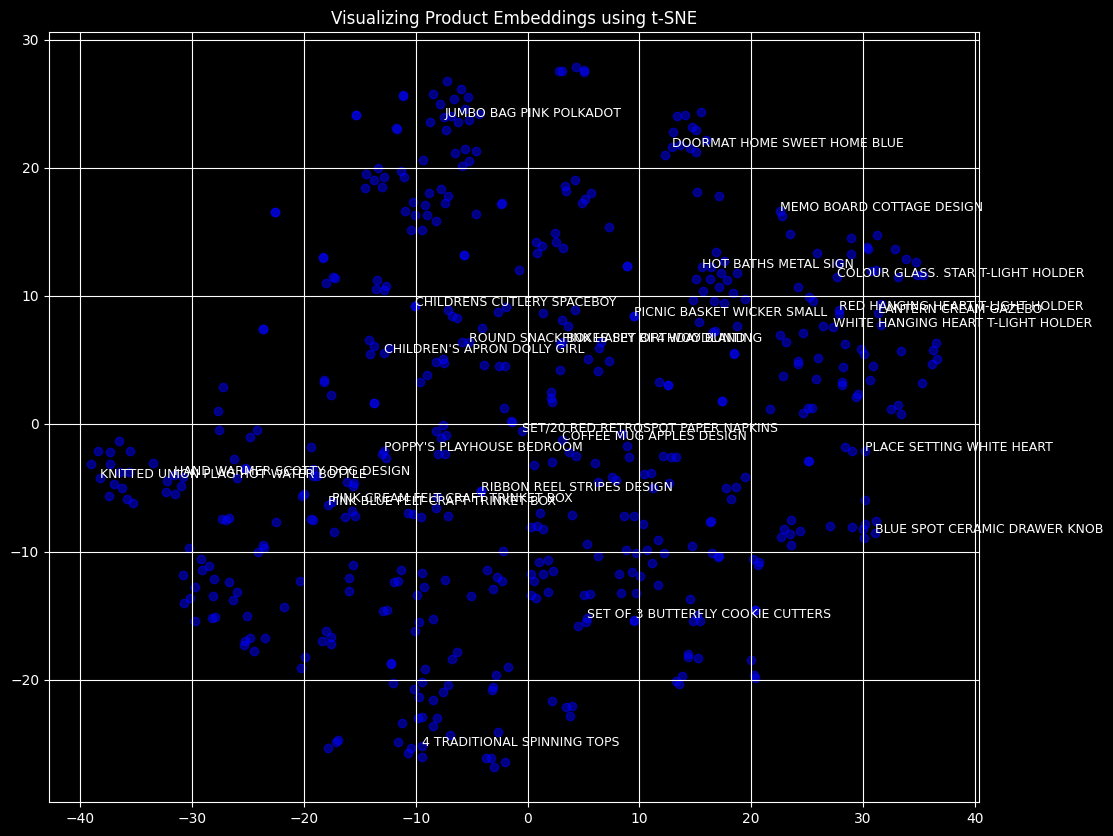

In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_embeddings(model, item_lookup, n_items=500):
    top_items = model.wv.index_to_key[:n_items]
    vectors = np.array([model.wv[item] for item in top_items])
    labels = [item_lookup.get(item, item) for item in top_items]

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, c='blue')

    for i in range(0, n_items, 20):
        plt.annotate(labels[i], (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9)

    plt.title("Visualizing Product Embeddings using t-SNE")
    plt.grid(True)
    plt.show()

plot_embeddings(model, item_lookup)

## UMAP

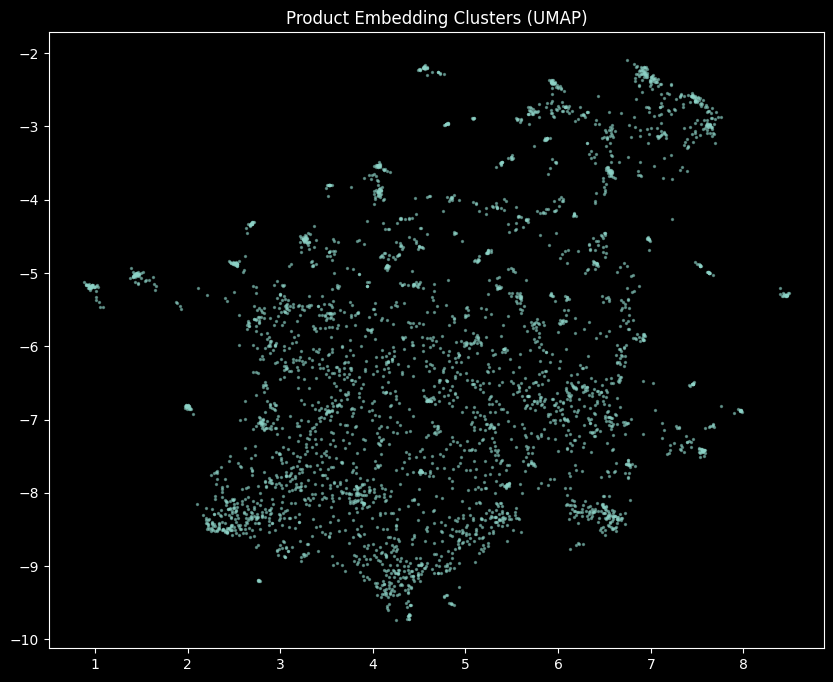

In [22]:
X = model.wv[list(model.wv.key_to_index)]
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=2, cmap='Spectral', alpha=0.5)
plt.title("Product Embedding Clusters (UMAP)")
plt.show()

## Final Recommender

In [23]:
products_dict = train_df[["StockCode", "Description"]].drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()

def show_recommendations(basket_index=0):
    sample_basket = purchases_val[basket_index]
    basket_vec = np.mean([model.wv[i] for i in sample_basket if i in model.wv], axis=0)
    recommendations = model.wv.most_similar(positive=[basket_vec], topn=5)

    print(f"\033[1m\033[96m--- Shopping Basket (Input) ---\033[0m")
    for i in sample_basket:
        print(f"• {products_dict.get(i, i)}")

    print(f"\n\033[1m\033[92m--- Recommended for this Customer ---\033[0m")
    for r in recommendations:
        print(f"✔ {products_dict.get(r[0], r[0])} (Score: {round(r[1], 3)})")

show_recommendations(0)

--- Shopping Basket (Input) ---
• MINI PLAYING CARDS DOLLY GIRL 
• MINI PLAYING CARDS SPACEBOY 
• CHRISTMAS TABLE CANDLE SILVER SPIKE
• PINK GOOSE FEATHER TREE 60CM
• WOODLAND CHARLOTTE BAG
• RABBIT NIGHT LIGHT
• RED TOADSTOOL LED NIGHT LIGHT
• PINK NEW BAROQUECANDLESTICK CANDLE
• BOOM BOX SPEAKER BOYS
• 23552
• CLASSIC CHROME BICYCLE BELL 

--- Recommended for this Customer ---
✔ MINI PLAYING CARDS DOLLY GIRL  (Score: 0.664)
✔ MINI PLAYING CARDS SPACEBOY  (Score: 0.661)
✔ Bank Charges (Score: 0.661)
✔ RED TOADSTOOL LED NIGHT LIGHT (Score: 0.633)
✔ RABBIT NIGHT LIGHT (Score: 0.631)
